<a href="https://colab.research.google.com/github/Kovibordy/ML-2.0/blob/main/%D0%BB%D0%B0%D0%B11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Решение задачи классификации и регрессии на основе многослойного перцептрона

### Вариант - 11

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.regularizers import L2
from tensorflow.keras.utils import set_random_seed
from tensorflow.keras.callbacks import EarlyStopping

Фиксация случайности

In [10]:
SEED = 42
set_random_seed(SEED)

Загружаем данные для классификации

In [15]:
df_class = pd.read_csv('classify11.csv')
print(df_class.head())

         F1        F2        F3        F4  Target
0 -3.402839  0.179845  1.432424  0.774566       1
1 -1.902995 -1.241501  1.956614  0.512447       1
2 -1.023094  1.270126  0.782203 -0.785725       0
3 -0.331077 -0.069590 -0.258279 -0.339054       0
4 -3.377452  0.816699 -3.009166 -1.553258       2


Загружаем данные для регресии

In [16]:
df_reg = pd.read_csv('regress11.csv')
print(df_reg.head())

         V1        V2        V3        V4      Target
0 -0.919424  0.473592 -1.062304  1.549934   75.609515
1 -0.321635 -0.349258 -0.348652  2.076748  112.863277
2 -2.123896 -0.599393 -0.839722 -0.525755  322.077288
3 -1.070892 -0.857158  0.625667  0.482472  189.972784
4 -0.082151  1.443765 -1.251539  1.117296  197.191068


## Предобработка данных

In [17]:
def preprocess_data(df, target_col, test_size=0.2, random_state=SEED):
    X = df.drop(columns=[target_col]).values
    y = df[target_col].values

    # Масштабирование признаков
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Разделение на train и test
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=random_state, stratify=None if target_col=='Target' else None
    )
    return X_train, X_test, y_train, y_test, scaler

X_train_cls, X_test_cls, y_train_cls, y_test_cls, scaler_cls = preprocess_data(df_class, 'Target')
print(f"Классификация: Train {X_train_cls.shape}, Test {X_test_cls.shape}")

X_train_reg, X_test_reg, y_train_reg, y_test_reg, scaler_reg = preprocess_data(df_reg, 'Target')
print(f"Регрессия: Train {X_train_reg.shape}, Test {X_test_reg.shape}")

Классификация: Train (160, 4), Test (40, 4)
Регрессия: Train (240, 4), Test (60, 4)


## Построение MLP для классификации

Будем использовать 3 нейрона

In [18]:
def create_classification_model(input_dim, num_classes=3):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['sparse_categorical_accuracy'])
    return model

model_cls = create_classification_model(X_train_cls.shape[1])
model_cls.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,499 (9.76 KB)

 Trainable params: 2,499 (9.76 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history_cls = model_cls.fit(
    X_train_cls, y_train_cls,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 1.0747 - sparse_categorical_accuracy: 0.4062 - val_loss: 1.0594 - val_sparse_categorical_accuracy: 0.4062
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9856 - sparse_categorical_accuracy: 0.5781 - val_loss: 0.9839 - val_sparse_categorical_accuracy: 0.6562
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9069 - sparse_categorical_accuracy: 0.7266 - val_loss: 0.9160 - val_sparse_categorical_accuracy: 0.8125
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.8361 - sparse_categorical_accuracy: 0.7734 - val_loss: 0.8544 - val_sparse_categorical_accuracy: 0.7188
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7716 - sparse_categorical_accuracy: 0.7812 - val_loss: 0.7982 - val_sparse_categorical_accuracy: 0.7188
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7138 - sparse_categorical_accuracy: 0.7891 - val_loss: 0.7495 - val_sparse_categorical_accuracy: 0.7188
Epoch 7/200
8/8 

Делаем визуализацию

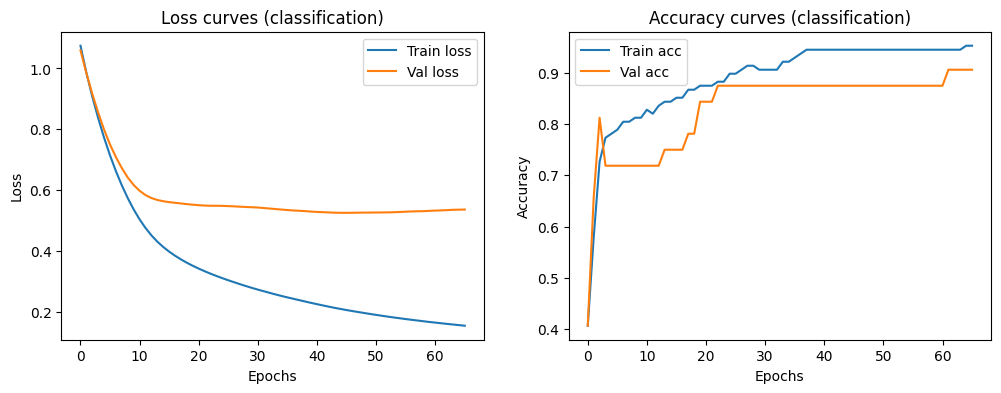

In [20]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_cls.history['loss'], label='Train loss')
plt.plot(history_cls.history['val_loss'], label='Val loss')
plt.title('Loss curves (classification)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_cls.history['sparse_categorical_accuracy'], label='Train acc')
plt.plot(history_cls.history['val_sparse_categorical_accuracy'], label='Val acc')
plt.title('Accuracy curves (classification)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Проводим оценку на тестовом наборе

In [21]:
test_loss, test_acc = model_cls.evaluate(X_test_cls, y_test_cls, verbose=0)
print(f"Классификация - Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

# Предсказания и метрики
y_pred_cls = np.argmax(model_cls.predict(X_test_cls), axis=1)
print(f"Accuracy (sklearn): {accuracy_score(y_test_cls, y_pred_cls):.4f}")

Классификация - Test accuracy: 0.8750, Test loss: 0.4603
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Accuracy (sklearn): 0.8750


## Построение MLP для регрессии

Функция потерь – MSE. Выходной слой – 1 нейрон без активации

In [22]:
def create_regression_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model_reg = create_regression_model(X_train_reg.shape[1])
model_reg.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,433 (9.50 KB)

 Trainable params: 2,433 (9.50 KB)

 Non-trainable params: 0 (0.00 B)

Проводим обучение

In [23]:
history_reg = model_reg.fit(
    X_train_reg, y_train_reg,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=[EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)],
    verbose=1
)

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 30563.8340 - mae: 156.1979 - val_loss: 32146.0000 - val_mae: 163.6984
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 30367.7754 - mae: 155.6199 - val_loss: 31911.1035 - val_mae: 163.0127
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 30104.4863 - mae: 154.8430 - val_loss: 31588.9473 - val_mae: 162.0704
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 29744.2832 - mae: 153.7734 - val_loss: 31155.9746 - val_mae: 160.7954
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 29265.1348 - mae: 152.3410 - val_loss: 30598.7891 - val_mae: 159.1388
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 28654.8887 - mae: 150.4989 - val_loss: 29906.8535 - val_mae: 157.0546
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 27899.4434 - mae: 148.1877 - val_loss: 29058.2109 - val_mae: 154.4588
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 26974.1426 - mae: 145.3082 - val_loss

Визуализируем

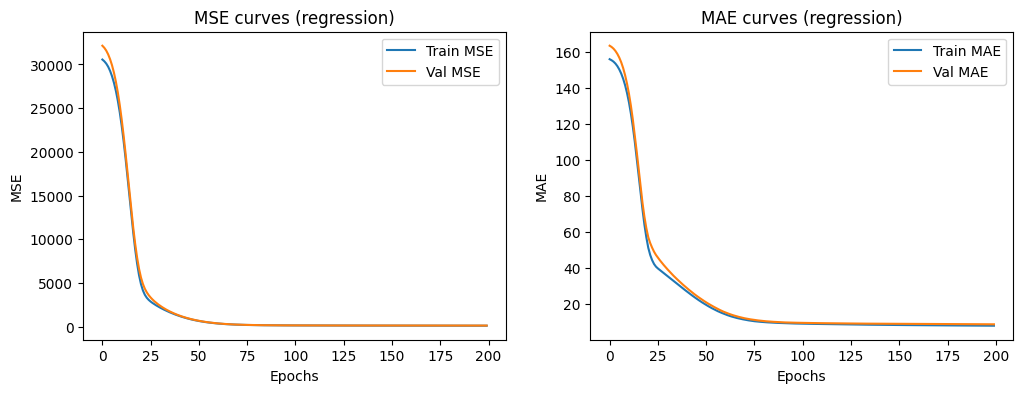

In [24]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_reg.history['loss'], label='Train MSE')
plt.plot(history_reg.history['val_loss'], label='Val MSE')
plt.title('MSE curves (regression)')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_reg.history['mae'], label='Train MAE')
plt.plot(history_reg.history['val_mae'], label='Val MAE')
plt.title('MAE curves (regression)')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

In [25]:
test_mse, test_mae = model_reg.evaluate(X_test_reg, y_test_reg, verbose=0)
print(f"Регрессия - Test MSE: {test_mse:.4f}, Test MAE: {test_mae:.4f}")

# Предсказания и дополнительные метрики
y_pred_reg = model_reg.predict(X_test_reg).flatten()
print(f"MSE (sklearn): {mean_squared_error(y_test_reg, y_pred_reg):.4f}")
print(f"MAE (sklearn): {mean_absolute_error(y_test_reg, y_pred_reg):.4f}")

Регрессия - Test MSE: 147.4498, Test MAE: 9.5628
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
MSE (sklearn): 147.4498
MAE (sklearn): 9.5628
